In [8]:
import torch
from sklearn import  metrics
from matplotlib import pyplot as plt
from sklearn import preprocessing as prep
from torch.utils.data import TensorDataset,DataLoader,Dataset
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.datasets import load_digits
from torch.nn import functional as F
import torchvision
from torchvision.transforms import ToTensor, Lambda
from torch import nn, optim

In [9]:
from torch.utils.data import DataLoader, random_split

# %% MNIST dataset
num_classes = 10
batch_size = 32

# target_transform = Lambda(
#     lambda y: torch.zeros(num_classes).scatter_(0, torch.tensor(y), 1)
# )

full_train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=ToTensor(),
    download=True
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform=ToTensor(),
)


In [10]:
train_size = 50000
val_size   = 10000

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size]
)


In [11]:
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


In [12]:
class LeNet05(nn.Module):
    def __init__(self,
                 in_channels=1,
                 out_channels1=6,
                 kernel_size1=(5,5),
                 pool_size1=(2,2),
                 
                 out_channels2=16,
                 kernel_size2=(5,5),
                 pool_size2=(2,2),
                 
                 n_fc1=120,
                 n_fc2=84,
                 n_fc3= 10):
        super(LeNet05, self).__init__()
        
        self.conv1= nn.Conv2d(in_channels=in_channels,
                              out_channels=out_channels1,
                              kernel_size=kernel_size1,
                              padding= (kernel_size1[0]//2, kernel_size1[1]//2),
                              groups=1)
        self.bn_c1= nn.BatchNorm2d(num_features=out_channels1,momentum=0.1)
        self.pool1= nn.MaxPool2d(kernel_size=pool_size1,
                                 stride=pool_size1)
        
        self.conv2= nn.Conv2d(in_channels=out_channels1,
                              out_channels=out_channels2,
                              kernel_size=kernel_size2,
                              groups=1)
        
        self.bn_c2= nn.BatchNorm2d(num_features=out_channels2,momentum=0.1)
        
        self.pool2= nn.MaxPool2d(kernel_size=pool_size2,
                                 stride=pool_size2)
       
        self.fc1= nn.LazyLinear(out_features=n_fc1)
        self.bn_f1= nn.BatchNorm1d(num_features=n_fc1,momentum=0.1)
        self.fc2= nn.LazyLinear(out_features=n_fc2)
        self.bn_f2= nn.BatchNorm1d(num_features=n_fc2,momentum=0.1)
        self.fc3= nn.LazyLinear(out_features=n_fc3)
        
        self.fun= nn.ReLU()
    
    def forward(self,X):
       # X: bs x 1 x H x W
       out= self.conv1(X)
       out= self.bn_c1(out)
       out= self.fun(out)
       out= self.pool1(out)
       
       out= self.conv2(out)
       out= self.bn_c2(out)
       out= self.fun(out)
       out= self.pool2(out)
       # flattening 
       flat= out.flatten(start_dim=1)
       out= self.fc1(flat)
       out= self.bn_f1(out)
       out= self.fun(out)
       
       out= self.fc2(out)
       out= self.bn_f2(out)
       out= self.fun(out)
       
       out= self.fc3(out)
       return out

In [13]:
model= LeNet05(in_channels=1,
                out_channels1=6,
                kernel_size1=(5,5),
                pool_size1=(2,2),
                
                out_channels2=16,
                kernel_size2=(5,5),
                pool_size2=(2,2),
                
                n_fc1=120,
                n_fc2=84,
                n_fc3= 10)
n_out=10

criterion= nn.CrossEntropyLoss()
optimizer= optim.Adam(params=model.parameters(),
                      lr=0.001)

In [14]:
mse=[]
epoch=2
for iter in range(epoch):
     er=[]
     for i,(xbatch,ybatch) in enumerate(train_loader):
          model.train()
          # farward pass
          ypred= model(xbatch)
          optimizer.zero_grad()
          loss= criterion(ypred,ybatch.long())
          loss.backward()
          optimizer.step()

          er.append(loss.detach()) 
          if i%5==0:
               model.eval()
               loss= torch.mean(torch.tensor(er))
               mse.append(loss)
               # validation
               with torch.no_grad():
                    y_pred=[]
                    y_true=[]
                    for j,(xbatch,ybatch) in enumerate(val_loader):
                         # farward pass
                         ypred= model(xbatch)
                         ypred= torch.argmax(ypred,dim=1)
                         y_pred.extend(ypred.numpy())
                         y_true.extend(ybatch.numpy())
                         
                    y_pred= np.array(y_pred)
                    y_true= np.array(y_true)
                    accuracy= np.sum(y_true==y_pred)/y_pred.shape[0]*100
                    print(f'MSE({iter}:{i}): {loss:.6f} **** Acc:{accuracy:.3f}%')
               model.train()
mse=torch.tensor(mse)

plt.subplot(2,1,1)
plt.plot(mse)
plt.show()

MSE(0:0): 2.301961 **** Acc:11.990%
MSE(0:5): 2.056678 **** Acc:18.350%
MSE(0:10): 1.842117 **** Acc:10.910%
MSE(0:15): 1.697048 **** Acc:10.870%
MSE(0:20): 1.573569 **** Acc:11.960%
MSE(0:25): 1.475127 **** Acc:21.650%
MSE(0:30): 1.393006 **** Acc:46.270%
MSE(0:35): 1.317185 **** Acc:71.450%
MSE(0:40): 1.243403 **** Acc:81.800%
MSE(0:45): 1.191599 **** Acc:85.610%
MSE(0:50): 1.134987 **** Acc:88.810%
MSE(0:55): 1.089442 **** Acc:91.000%
MSE(0:60): 1.043649 **** Acc:91.940%
MSE(0:65): 0.999674 **** Acc:92.670%
MSE(0:70): 0.967740 **** Acc:92.710%
MSE(0:75): 0.932926 **** Acc:93.020%
MSE(0:80): 0.900418 **** Acc:92.860%
MSE(0:85): 0.871611 **** Acc:93.300%
MSE(0:90): 0.845098 **** Acc:93.680%
MSE(0:95): 0.823514 **** Acc:93.570%
MSE(0:100): 0.803316 **** Acc:93.810%
MSE(0:105): 0.782810 **** Acc:94.060%
MSE(0:110): 0.761944 **** Acc:94.510%
MSE(0:115): 0.745052 **** Acc:94.660%
MSE(0:120): 0.725455 **** Acc:94.570%
MSE(0:125): 0.705639 **** Acc:94.660%
MSE(0:130): 0.689671 **** Acc:94.9

KeyboardInterrupt: 

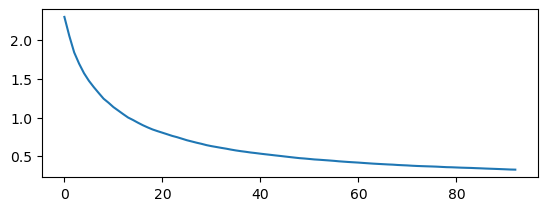

In [16]:
plt.subplot(2,1,1)
plt.plot(mse)
plt.show()

Total accuracy:97.510%
accuracy0:96.837%
accuracy1:99.119%
accuracy2:98.062%
accuracy3:97.624%
accuracy4:97.047%
accuracy5:97.422%
accuracy6:98.434%
accuracy7:97.471%
accuracy8:97.536%
accuracy9:95.342%


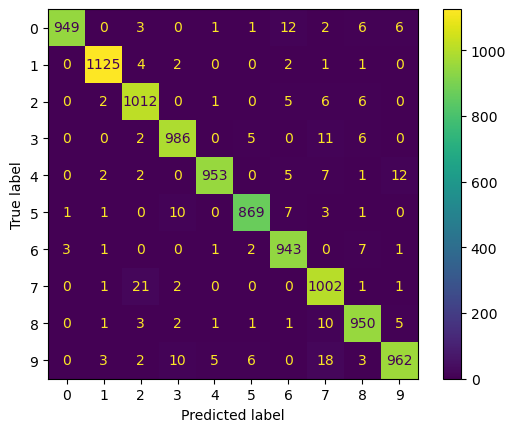

In [15]:
# validation
y_pred=[]
y_true=[]
model.eval()
with torch.no_grad():
    for i,(xbatch,ybatch) in enumerate(test_loader):
        # farward pass
        ypred= model(xbatch)
        ypred= torch.argmax(ypred,dim=1)
        y_pred.extend(ypred.numpy())
        y_true.extend(ybatch.numpy())
        
    y_pred= np.array(y_pred)
    y_true= np.array(y_true)

    from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
    #%% test trained Neural Network
    C= confusion_matrix(y_true,y_pred)
    # print(C)
    accuracy= np.sum(np.diag(C))/ np.sum(C) *100
    print(f'Total accuracy:{accuracy:.3f}%')

for i in range(n_out):
    accuracyi= C[i,i]/ np.sum(C[i,:]) *100
    print(f'accuracy{i}:{accuracyi:.3f}%')
# plt.figure()
disp= ConfusionMatrixDisplay(C)
disp.plot()
plt.show()